# Lecture 07, Notebook 04: IRBC via Autodiff (Self-Study)

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §2.7 (autodiff template) applied to the IRBC model of Ch. 3 (§3.x)  
**Notebook role:** extension  
**Original live-course source:** `lectures/lecture_06_B05_autodiff_for_deqns/notebooks/extensions/lecture_06_B05_04_IRBC_AutoDiff_DEQN.ipynb`  
**Author:** Simon Scheidegger  


In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


In [ ]:
# Chapter-wide RUN_MODE budget helper -- maps RUN_MODE to a training budget.
_BUDGET = {
    "smoke":       400,    # quick CI sweep
    "teaching":   2000,    # default teaching run
    "production": 5000,    # publication run
}
NUM_EPISODES = _BUDGET[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}: NUM_EPISODES={NUM_EPISODES}")


# Notebook 03b — IRBC (basic model) via Automatic Differentiation

> **Status: additional materials / self-study.** This notebook is *not* covered in the
> Day 4 lecture slot. It revisits the Day 3 baseline IRBC model
> (`lectures/lecture_04_irbc_with_deqns/code/lecture_04_01_IRBC_DEQN_smooth.ipynb`) using the autodiff template developed in Day 4
> notebooks 02 and 03, scaled up from a single-state Brock–Mirman to a multi-country,
> multi-equation planner problem with adjustment costs and an irreversibility KKT
> complementarity.

## Learning goals

By the end of this notebook you will be able to:

1. **Identify the planner Lagrangian as the autodiff handle.** In the IRBC model,
   the per-country contribution $\Pi^j(k_{\text{in}}, k'_{\text{out}}, z; \lambda, \mu^j)$
   to the planner Lagrangian is the *only* user-supplied object — every Euler
   residual comes out of two `tf.GradientTape` calls.
2. **Derive on paper, then implement, the exact correspondence**
   $$\partial_2 \Pi^j + \beta\,\mathbb{E}[\partial_1 \Pi^j] \;=\; 0$$
   and verify it agrees with the Day 3 *hand-derived* Euler residual to machine
   precision.
3. **See what stays hand-coded.** The aggregate resource constraint (ARC) and the
   Fischer–Burmeister complementarity for irreversibility are *not* envelope outputs,
   so autodiff has nothing to add. We document why and keep them as simple algebra.
4. **Compare two sampling strategies** under the autodiff loss with the *same*
   architecture, *same* training budget, and *no* loss balancing (no ReLoBRaLo):
   - **Approach A** — exogenous uniform sampling.
   - **Approach B** — simulation-based (endogenous) sampling.

## What is *not* in this notebook
- ReLoBRaLo loss balancing — covered in Day 3 nb 01 Approach D and the lecture
  script. The point of the present notebook is the autodiff template, not loss
  balancing. Reintroducing ReLoBRaLo on top of the autodiff residual is a
  one-evening exercise.
- Pre-training (Day 3 Approach C). Could be added as a standalone block, but
  Approaches A and B already make the sampling-strategy comparison clean.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import itertools

plt.rcParams['font.size'] = 13
%matplotlib inline

# Reproducibility (SEED from cell 2)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")


2026-04-22 21:49:31.522803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776887371.543193   39110 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776887371.549044   39110 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 21:49:31.568472: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
Eager mode: True


## 1. The planner problem

A Pareto-weighted social planner with weights $\tau^j$ chooses
$\{c^j_t,\, k^{j\prime}_t,\, \mu^j_t,\, \lambda_t\}_{j=1\ldots N}$ to maximize

$$\mathbb{E}_0 \sum_{t=0}^\infty \beta^t \sum_{j=1}^N \tau^j\, u^j(c^j_t),
\qquad u^j(c) = \frac{c^{1-1/\gamma_j}}{1-1/\gamma_j},$$

subject to

| Constraint | Equation |
|---|---|
| Aggregate resource constraint (ARC) | $\sum_j\!\bigl[c^j_t + k^{j\prime}_t + \Gamma(k^j_t,k^{j\prime}_t)\bigr] = \sum_j\!\bigl[Y^j(k^j_t,z^j_t) + (1-\delta)k^j_t\bigr]$ |
| Irreversibility | $I^j_t \;\equiv\; k^{j\prime}_t - (1-\delta)k^j_t \;\ge\; 0$ |
| Production | $Y^j_t = A_{\rm tfp}\, e^{z^j_t}\, (k^j_t)^\zeta$ |
| Adjustment cost | $\Gamma(k, k') = \tfrac{\kappa}{2}\, k\, (k'/k - 1)^2$ |
| Exogenous TFP | $z^{j\prime}_t = \rho_z z^j_t + \sigma_e\,(\varepsilon^j_{t+1} + \varepsilon^{\rm agg}_{t+1})$, $\varepsilon \sim \mathcal{N}(0, 1)$ |

The TFP calibration $A_{\rm tfp} = (1-\beta(1-\delta)) / (\zeta\beta)$ pins the
deterministic steady state at $k_{\rm ss} = 1$.

**The same model as Day 3 nb 01.** Our goal is to re-solve it without ever writing
down a partial derivative on paper.

## 2. Lagrangian

Attach $\lambda_t$ to the ARC and $\mu^j_t$ to each irreversibility constraint:

$$\mathcal{L}_t \;=\; \sum_j \tau^j\, u^j(c^j_t)
\;+\; \lambda_t \sum_j\!\Bigl[Y^j_t + (1-\delta)k^j_t - k^{j\prime}_t - \Gamma^j_t - c^j_t\Bigr]
\;+\; \sum_j \mu^j_t\,I^j_t.$$

Both multipliers are **policy-network outputs**, not auxiliary variables — exactly
the layout of Day 3 nb 01:

- State: $\mathbf{s}_t = [k^1_t, \ldots, k^N_t,\; z^1_t, \ldots, z^N_t]$ — dimension $2N$.
- Policy: $\mathcal{N}_\rho(\mathbf{s}_t) = [k^{1\prime}_t, \ldots, k^{N\prime}_t,\; \lambda_t,\; \mu^1_t, \ldots, \mu^N_t]$ — dimension $2N+1$.

The consumption FOC $\partial \mathcal{L}_t / \partial c^j_t = \tau^j u^{j\prime}(c^j) - \lambda = 0$ gives

$$c^j(\lambda) \;=\; \bigl(\lambda/\tau^j\bigr)^{-\gamma_j},$$

so $c^j$ is *not* a separate network output — it is recovered from $\lambda$ in closed form.

In [2]:
# ============================================================
# Parameters (identical to Day 3 nb 01, cell [3])
# ============================================================
N_COUNTRIES = 2

# Preferences
beta      = 0.99
gamma_min = 0.25
gamma_max = 1.0

# Production
zeta  = 0.36
delta = 0.01

# TFP process
rho_z   = 0.95
sigma_e = 0.01

# Adjustment costs
kappa = 0.5

# Steady state
k_ss = 1.0

# Derived: TFP calibration s.t. MPK_ss = 1/beta
A_tfp = (1.0 - beta * (1.0 - delta)) / (zeta * beta)

# Country-specific risk aversion: gamma_j linearly spaced
if N_COUNTRIES == 1:
    gammas = [gamma_min]
else:
    gammas = [gamma_min + i * (gamma_max - gamma_min) / (N_COUNTRIES - 1)
              for i in range(N_COUNTRIES)]

# Pareto weights: tau_j = (A_tfp - delta)^(1/gamma_j); at the symmetric SS (c_ss = A_tfp - delta)
    # every country shares lambda_ss = 1 regardless of heterogeneous gamma_j
    # (matches day3/01_IRBC_DEQN_smooth and the script eq:irbc_pareto).
taus = [(A_tfp - delta) ** (1.0 / g) for g in gammas]

# Dimensions
n_states   = 2 * N_COUNTRIES        # [k_1,...,k_N, z_1,...,z_N]
n_policies = 2 * N_COUNTRIES + 1    # [kp_1,...,kp_N, lambda, mu_1,...,mu_N]
n_shocks   = N_COUNTRIES + 1        # N country-specific + 1 aggregate

# Numerical safety
EPS_SAFE = 1e-10

print(f"N_COUNTRIES = {N_COUNTRIES}")
print(f"A_tfp       = {A_tfp:.6f}")
print(f"gammas      = {gammas}")
print(f"taus        = {[f'{t:.6f}' for t in taus]}")
print(f"States: {n_states},  Policies: {n_policies},  Shocks: {n_shocks}")


N_COUNTRIES = 2
A_tfp       = 0.055836
gammas      = [0.25, 1.0]
taus        = ['0.000010', '0.055836']
States: 4,  Policies: 5,  Shocks: 3


In [3]:
# Deterministic steady state (z=0, k=k_ss, mu=0): used both for sanity-check
# and as an evaluation reference.
Y_ss            = A_tfp * np.exp(0.0) * k_ss ** zeta
I_ss            = delta * k_ss
adj_cost_ss     = 0.0
MPK_ss          = 1.0 - delta + zeta * A_tfp * k_ss ** (zeta - 1)
c_ss            = Y_ss + (1.0 - delta) * k_ss - k_ss - adj_cost_ss
lambda_ss_list  = [taus[j] * c_ss ** (-1.0 / gammas[j]) for j in range(N_COUNTRIES)]
lambda_ss       = lambda_ss_list[0]   # equal across j by calibration

print("Steady state")
print(f"  Y_ss  = {Y_ss:.6f}")
print(f"  c_ss  = {c_ss:.6f}")
print(f"  MPK_ss = {MPK_ss:.6f}  (target 1/beta = {1.0/beta:.6f})")
print(f"  lambda_ss per country = {[f'{v:.6f}' for v in lambda_ss_list]}")
print(f"  ARC residual at ss     = {N_COUNTRIES * (Y_ss - I_ss - c_ss):.2e}")


Steady state
  Y_ss  = 0.055836
  c_ss  = 0.045836
  MPK_ss = 1.010101  (target 1/beta = 1.010101)
  lambda_ss per country = ['2.202061', '1.218168']
  ARC residual at ss     = -4.16e-17


## 3. Gauss–Hermite quadrature for the conditional expectation

Each TFP innovation is $\mathcal{N}(0,1)$; the AR(1) law of motion turns
$\mathbb{E}_t[f(z_{t+1})]$ into a Gaussian integral that we approximate by
Gauss–Hermite. With $Q$ nodes per dimension and $N+1$ shocks (N country-specific +
1 aggregate), the tensor product gives $Q^{N+1}$ nodes.

We use $Q = 3 \Rightarrow Q^{N+1} = 27$ nodes for $N = 2$ — the same setup as Day 3.

In [4]:
# Gauss-Hermite for N(0,1)
Q = 3
nodes_1d, weights_1d = np.polynomial.hermite.hermgauss(Q)
nodes_1d   = nodes_1d * np.sqrt(2.0)        # rescale for N(0,1)
weights_1d = weights_1d / np.sqrt(np.pi)    # normalize

# Tensor product over n_shocks dimensions
indices       = list(itertools.product(range(Q), repeat=n_shocks))
quad_nodes    = np.array([[nodes_1d[idx]   for idx in combo] for combo in indices])
quad_weights  = np.array([np.prod([weights_1d[idx] for idx in combo]) for combo in indices])

quad_nodes_tf   = tf.constant(quad_nodes,   dtype=tf.float32)
quad_weights_tf = tf.constant(quad_weights, dtype=tf.float32)
n_quad_total    = len(quad_weights)

print(f"Q = {Q} per dim, n_shocks = {n_shocks}, total quadrature nodes = {n_quad_total}")
print(f"Weights sum = {np.sum(quad_weights):.6f} (should be 1.0)")


Q = 3 per dim, n_shocks = 3, total quadrature nodes = 27
Weights sum = 1.000000 (should be 1.0)


2026-04-22 21:49:34.512143: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 4. Neural network architecture

Identical to Day 3 nb 01: 2 hidden layers × 64 units, swish activation, softplus
output. The softplus output enforces $k^{j\prime}_t > 0$, $\lambda_t > 0$,
$\mu^j_t > 0$ at every iteration of training (a *hard constraint*, in the sense of
Day 4 nb 02). The Euler equation, the ARC, and the FB complementarity are then
enforced *softly* through the loss.

In [5]:
def build_network():
    nn = keras.Sequential([
        keras.layers.Dense(64, activation='swish', input_shape=(n_states,)),
        keras.layers.Dense(64, activation='swish'),
        keras.layers.Dense(n_policies, activation='softplus'),
    ])
    return nn

nn_demo = build_network()
nn_demo.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,805 (18.77 KB)

 Trainable params: 4,805 (18.77 KB)

 Non-trainable params: 0 (0.00 B)

## 5. The autodiff handle — a per-country Lagrangian primitive

The Lagrangian decomposes additively across countries:

$$\mathcal{L}_t \;=\; \sum_{j=1}^N \Pi^j\!\bigl(k^j_t,\, k^{j\prime}_t,\, z^j_t;\, \lambda_t,\, \mu^j_t\bigr),$$

where the *single user-supplied object* is

$$\boxed{\;\Pi^j\!\bigl(\underbrace{k^j_{\text{in}}}_{\text{slot 1: STATE}},\,
                 \underbrace{k^{j\prime}_{\text{out}}}_{\text{slot 2: CHOICE}},\,
                 z^j_{\text{in}};\;
                 \lambda,\, \mu^j\bigr)
\;\;=\;\; \tau^j\, u^j\!\bigl(c^j(\lambda)\bigr)
\;+\; \lambda\!\Bigl[Y^j(k^j_{\text{in}}, z^j_{\text{in}}) + (1-\delta)k^j_{\text{in}}
                    - k^{j\prime}_{\text{out}} - \Gamma(k^j_{\text{in}}, k^{j\prime}_{\text{out}})
                    - c^j(\lambda)\Bigr]
\;+\; \mu^j\!\bigl[k^{j\prime}_{\text{out}} - (1-\delta)k^j_{\text{in}}\bigr]\;}$$

with $c^j(\lambda) = (\lambda/\tau^j)^{-\gamma_j}$.

### Why we encode it this way

- **Slot 1 = state.** Differentiating $\Pi^j$ in slot 1, evaluated at *next period*'s
  $(k', k'', z')$, returns the envelope term — see §6.
- **Slot 2 = choice.** Differentiating in slot 2, evaluated at *this period*'s
  $(k, k', z)$, returns the FOC term — see §6.
- **Shock and multipliers** enter as fixed parameters held outside the two tapes.
  In particular we *do not* differentiate $\Pi^j$ in $\lambda$ or $\mu^j$ to obtain
  the Euler residual: the multipliers' own FOCs are encoded by the ARC and the
  Karush–Kuhn–Tucker complementarity, not by the Euler equation. See §8.

> **Pedagogical note.** The Pareto-weight utility term $\tau^j u^j(c^j(\lambda))$
> contributes $0$ to both $\partial_1 \Pi^j$ and $\partial_2 \Pi^j$ (no $k$/$k'$
> dependence). We *keep* it in $\Pi^j$ for clarity — it makes the connection to
> "this is the planner Lagrangian" explicit, and it is the term that *would* matter
> if you instead differentiated in $\lambda$ to recover the ARC.

## 6. Hard helpers (algebraic functions, no derivatives needed)

Production, adjustment-cost *value*, investment, consumption-from-FOC, and the
Fischer–Burmeister function. We do **not** code `production_k`, `mpk`, `adj_cost_k`,
or `adj_cost_kp` — those are exactly the hand-derived helpers we are *replacing*
with autodiff.

In [6]:
# ============================================================
# Production:  Y = A_tfp * exp(z) * k^zeta
# ============================================================
def production(k, z):
    return A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta)

# ============================================================
# Adjustment cost VALUE only:  Gamma = 0.5 * kappa * k * (k'/k - 1)^2
# ============================================================
def adj_cost(k, kp):
    k_safe = tf.maximum(k, EPS_SAFE)
    j      = kp / k_safe - 1.0
    return 0.5 * kappa * j * j * k_safe

# ============================================================
# Investment:  I = k' - (1-delta)*k
# ============================================================
def investment(k, kp):
    return kp - (1.0 - delta) * k

# ============================================================
# Consumption from the planner's c-FOC:  c_j = (lambda/tau_j)^(-gamma_j)
# ============================================================
def consumption(lamb, j):
    return tf.pow(lamb / taus[j], -gammas[j])

# ============================================================
# CRRA utility (kept SEPARATELY so it can appear inside Pi).
# Note: u^j has zero derivative w.r.t. k_in / kp_out (it depends only on lambda),
# so its value never enters the Euler residual. We keep it in Pi only for
# pedagogical clarity ("this IS the planner Lagrangian"). The gamma=1 limit
# is log-utility -- handled explicitly so the forward value stays finite.
# ============================================================
def utility(c, j):
    g = gammas[j]
    if abs(g - 1.0) < 1e-12:
        return tf.math.log(tf.maximum(c, EPS_SAFE))
    return tf.pow(tf.maximum(c, EPS_SAFE), 1.0 - 1.0 / g) / (1.0 - 1.0 / g)

# ============================================================
# Fischer-Burmeister:  mu + I - sqrt(mu^2 + I^2 + eps)  (smooth KKT)
# ============================================================
def fischer_burmeister(mu, I_val, eps=1e-8):
    return mu + I_val - tf.sqrt(mu * mu + I_val * I_val + eps)

# ============================================================
# State / policy accessors  (state layout = [k_1..k_N, z_1..z_N];
#                            policy layout = [kp_1..kp_N, lambda, mu_1..mu_N])
# ============================================================
def get_k     (states,   j): return states  [:, j           : j           + 1]
def get_z     (states,   j): return states  [:, N_COUNTRIES + j : N_COUNTRIES + j + 1]
def get_kp    (policies, j): return policies[:, j           : j           + 1]
def get_lamb  (policies   ): return policies[:, N_COUNTRIES : N_COUNTRIES + 1]
def get_mu    (policies, j): return policies[:, N_COUNTRIES + 1 + j : N_COUNTRIES + 2 + j]

print("Hard helpers and accessors defined.")


Hard helpers and accessors defined.


### The primitive `Pi(k_in, kp_out, z_in, lamb, mu_j, j)`

Implements the boxed expression above term by term. This is the *only* place the
economics of the IRBC model enters the loss: change $u^j$, $Y^j$, or $\Gamma$ here
and nothing else moves.

In [7]:
def Pi(k_in, kp_out, z_in, lamb, mu_j, j):
    """Per-country planner Lagrangian contribution.

    Slot 1 (k_in)   = STATE  k^j today (or k^{j\prime} when used in the envelope tape).
    Slot 2 (kp_out) = CHOICE k^{j\prime} today (or k^{j\prime\prime} in the envelope tape).
    Slot 3 (z_in)   = exogenous shock z^j (parameter, not differentiated by Euler tapes).
    lamb, mu_j      = policy-network outputs at the relevant date (parameters).
    j               = country index (Python int, fixes gamma_j and tau_j).
    """
    # 1. Pareto-weighted utility (depends only on lambda, not on k/kp)
    c_j = consumption(lamb, j)
    util_term = taus[j] * utility(c_j, j)

    # 2. lambda * [Y + (1-delta)k - kp - Gamma - c]
    Y_j     = production(k_in, z_in)
    Gamma_j = adj_cost(k_in, kp_out)
    arc_term_j = lamb * (Y_j + (1.0 - delta) * k_in - kp_out - Gamma_j - c_j)

    # 3. mu_j * [kp - (1-delta) k]   (irreversibility multiplier x investment)
    irr_term = mu_j * (kp_out - (1.0 - delta) * k_in)

    return util_term + arc_term_j + irr_term

# Quick sanity check — pure forward evaluation, no gradients yet (force float32)
k_test  = tf.constant([[1.0], [1.1]],            dtype=tf.float32)
kp_test = tf.constant([[1.0], [1.2]],            dtype=tf.float32)
z_test  = tf.constant([[0.0], [0.05]],           dtype=tf.float32)
lam_t   = tf.constant([[lambda_ss], [lambda_ss]], dtype=tf.float32)
mu_t    = tf.constant([[1e-6], [1e-6]],          dtype=tf.float32)
print("Pi values (j=0):", Pi(k_test, kp_test, z_test, lam_t, mu_t, 0).numpy().flatten())
print("Pi values (j=1):", Pi(k_test, kp_test, z_test, lam_t, mu_t, 1).numpy().flatten())


Pi values (j=0): [-0.03364476 -0.2502414 ]
Pi values (j=1): [-0.16008484 -0.3766815 ]


## 7. From `Pi` to the Euler residual via two `tape.gradient` calls

### 7.1 Pen-and-paper FOC for $k^{j\prime}_t$

Differentiating $\mathcal{L}_t + \beta\,\mathbb{E}_t \mathcal{L}_{t+1}$ in
$k^{j\prime}_t$ — a choice today, a state tomorrow:

$$\frac{\partial \mathcal{L}_t}{\partial k^{j\prime}_t}
\;+\; \beta\,\mathbb{E}_t\!\left[\frac{\partial \mathcal{L}_{t+1}}{\partial k^j_{t+1}}\right]
\;=\; 0.$$

Inside $\mathcal{L}_t = \sum_i \Pi^i$, only $\Pi^j$ depends on $k^{j\prime}_t$, so
the FOC collapses to

$$\boxed{\;\partial_2 \Pi^j\bigl(k^j_t,\, k^{j\prime}_t,\, z^j_t;\, \lambda_t,\, \mu^j_t\bigr)
\;+\; \beta\,\mathbb{E}_t\!\left[\partial_1 \Pi^j\bigl(k^{j\prime}_t,\, k^{j\prime\prime}_t,\, z^j_{t+1};\, \lambda_{t+1},\, \mu^j_{t+1}\bigr)\right]
\;=\; 0.\;}$$

This is the **same `partial_2 + beta * E[partial_1]` template as Day 4 nb 02–03**,
applied $N$ times.

### 7.2 What each `tape.gradient` returns — term by term

**FOC term** $\;\partial_2 \Pi^j$ at $(k^j_t,\, k^{j\prime}_t,\, z^j_t;\, \lambda_t,\, \mu^j_t)$:

| term in $\Pi^j$ | $\partial / \partial k^{j\prime}_{\text{out}}$ |
|---|---|
| $\tau^j u^j(c^j(\lambda))$ | $0$ |
| $\lambda\bigl(Y^j(k_{\text{in}}, z) + (1-\delta)k_{\text{in}} - c^j(\lambda)\bigr)$ | $0$ |
| $-\lambda\, k^{j\prime}_{\text{out}}$ | $-\lambda$ |
| $-\lambda\,\Gamma(k_{\text{in}}, k^{j\prime}_{\text{out}})$ | $-\lambda\,\Gamma_{k'}$ |
| $\mu^j\, k^{j\prime}_{\text{out}}$ | $+\mu^j$ |

$$\Rightarrow\quad \partial_2 \Pi^j \;=\; -\lambda\bigl(1 + \Gamma_{k'}\bigr) + \mu^j.$$

**Envelope term** $\;\partial_1 \Pi^j$ at $(k^{j\prime}_t,\, k^{j\prime\prime}_t,\, z^j_{t+1};\, \lambda_{t+1},\, \mu^j_{t+1})$:

| term in $\Pi^j$ | $\partial / \partial k^{j}_{\text{in}}$ |
|---|---|
| $\tau^j u^j(c^j(\lambda))$ | $0$ |
| $\lambda\,Y^j(k_{\text{in}},z_{\text{in}})$ | $\lambda\,F_k$ |
| $\lambda(1-\delta)k_{\text{in}}$ | $\lambda(1-\delta)$ |
| $-\lambda\,\Gamma(k_{\text{in}}, k^{j\prime}_{\text{out}})$ | $-\lambda\,\Gamma_k$ |
| $-\mu^j(1-\delta) k_{\text{in}}$ | $-(1-\delta)\mu^j$ |

$$\Rightarrow\quad \partial_1 \Pi^j \;=\; \lambda\bigl(1-\delta + F_k - \Gamma_k\bigr) - (1-\delta)\mu^j
                                       \;=\; \lambda \cdot \mathrm{MPK}^j - (1-\delta)\mu^j.$$

Substituting into the boxed Euler equation,

$$-\lambda_t\bigl(1+\Gamma_{k'}^t\bigr) + \mu^j_t
\;+\; \beta\,\mathbb{E}_t\!\bigl[\lambda_{t+1}\,\mathrm{MPK}^j_{t+1} - (1-\delta)\mu^j_{t+1}\bigr] \;=\; 0,$$

which is *exactly* the Day 3 Euler equation, in absolute (not relative) form.

### 7.3 Code-level slot table

| Math symbol | `Pi` argument | Watched by tape? |
|---|---|---|
| $k^j_{\text{in}}$ | 1 | yes (envelope tape) |
| $k^{j\prime}_{\text{out}}$ | 2 | yes (FOC tape) |
| $z^j_{\text{in}}$ | 3 | no — parameter |
| $\lambda$ | 4 | no — parameter |
| $\mu^j$ | 5 | no — parameter |
| $j$ | 6 | Python loop index |

The tapes only `watch()` the capital tensor in the relevant slot; the multipliers
and shocks are passed in as constants. This guarantees the gradient computed is the
Euler residual, not some other partial of the Lagrangian.

## 8. The autodiff cost function

Two `tf.GradientTape` blocks per country, plus the hand-coded ARC and FB.

We build the Euler residual for country $j$ in three steps inside `@tf.function`:

1. Roll $(k_t, z_t)$ forward to $k_{t+1}$ via the network → form the FOC tape on
   $\Pi^j(k^j_t, k^{j\prime}_t, z^j_t)$, watching slot 2.
2. For each Gauss–Hermite node, draw $z^j_{t+1}$, roll to $k_{t+2}$, form the
   envelope tape on $\Pi^j(k^{j\prime}_t, k^{j\prime\prime}_t, z^j_{t+1})$,
   watching slot 1, and accumulate the weighted sum.
3. Combine: `euler_res_j = dPi_dKout + beta * E[dPi_dKin]`.

ARC and FB are hand-coded — see §9 for *why*.

In [8]:
@tf.function
def compute_cost_autodiff(states, nn):
    """Mean squared equilibrium residuals via autodiff.

    Returns (loss, euler_residuals_list, arc_residual, fb_residuals_list).
    """
    policies = nn(states)
    lamb_t   = get_lamb(policies)

    # ---- Pre-compute next-period state for every quadrature node, once ----
    # next_state[q] depends on the SHOCK q but the same kp_t for all q.
    # We build them as Python list of length n_quad_total.
    next_states = []
    for q in range(n_quad_total):
        shock_q = quad_nodes_tf[q]               # shape [n_shocks]
        eps_agg = shock_q[n_shocks - 1]
        parts = []
        for jj in range(N_COUNTRIES):
            parts.append(get_kp(policies, jj))   # k^{j\prime}_t
        for jj in range(N_COUNTRIES):
            z_jj   = get_z(states, jj)
            z_next = rho_z * z_jj + sigma_e * (shock_q[jj] + eps_agg)
            parts.append(z_next)
        next_states.append(tf.concat(parts, axis=1))
    next_policies = [nn(ns) for ns in next_states]

    # =====================================================================
    # Euler residuals (autodiff): one per country
    # =====================================================================
    euler_residuals = []
    for j in range(N_COUNTRIES):
        k_t   = get_k (states,   j)
        kp_t  = get_kp(policies, j)
        z_t   = get_z (states,   j)
        mu_t  = get_mu(policies, j)

        # ---- FOC tape: differentiate Pi in slot 2 (kp_out) at (k_t, kp_t, z_t)
        with tf.GradientTape() as tape_foc:
            tape_foc.watch(kp_t)
            pi_t = Pi(k_t, kp_t, z_t, lamb_t, mu_t, j)
        dPi_dKout = tape_foc.gradient(pi_t, kp_t)
        # Mathematically equals  -lambda*(1 + Gamma_{k'}) + mu_j  -- never written by hand.

        # ---- Envelope tape under expectation: differentiate Pi in slot 1 (k_in)
        # at (k_in = kp_t, kp_out = k_{t+2}, z_in = z_{t+1}; lamb_{t+1}, mu^j_{t+1})
        expectation = tf.zeros_like(lamb_t)
        for q in range(n_quad_total):
            w_q          = quad_weights_tf[q]
            ns_q         = next_states[q]
            np_q         = next_policies[q]
            z_next_j     = get_z (ns_q, j)
            kp_next_j    = get_kp(np_q, j)
            lamb_next_q  = get_lamb(np_q)
            mu_next_j_q  = get_mu (np_q, j)

            with tf.GradientTape() as tape_env:
                tape_env.watch(kp_t)
                pi_tp1 = Pi(kp_t, kp_next_j, z_next_j, lamb_next_q, mu_next_j_q, j)
            dPi_dKin = tape_env.gradient(pi_tp1, kp_t)
            # Mathematically equals  lambda' * MPK^{j\prime} - (1-delta)*mu^{j\prime}.

            expectation = expectation + w_q * dPi_dKin

        euler_res_j = dPi_dKout + beta * expectation
        euler_residuals.append(euler_res_j)

    # =====================================================================
    # Aggregate Resource Constraint -- HAND-CODED (algebraic, see §9)
    # =====================================================================
    arc_residual = tf.zeros_like(lamb_t)
    for j in range(N_COUNTRIES):
        k_j  = get_k(states,   j)
        z_j  = get_z(states,   j)
        kp_j = get_kp(policies, j)
        Y_j     = production(k_j, z_j)
        c_j     = consumption(lamb_t, j)
        Gamma_j = adj_cost(k_j, kp_j)
        arc_residual = arc_residual + (Y_j + (1.0 - delta) * k_j - kp_j - Gamma_j - c_j)

    # =====================================================================
    # Fischer-Burmeister complementarity -- HAND-CODED (KKT, see §9)
    # =====================================================================
    fb_residuals = []
    for j in range(N_COUNTRIES):
        k_j  = get_k (states,   j)
        kp_j = get_kp(policies, j)
        mu_j = get_mu(policies, j)
        I_j  = investment(k_j, kp_j)
        fb_residuals.append(fischer_burmeister(mu_j, I_j))

    # =====================================================================
    # Total loss = mean of summed squares
    # =====================================================================
    total_sq = tf.zeros_like(lamb_t)
    for e  in euler_residuals: total_sq = total_sq + e  ** 2
    total_sq = total_sq + arc_residual ** 2
    for fb in fb_residuals:    total_sq = total_sq + fb ** 2
    loss = tf.reduce_mean(total_sq)

    return loss, euler_residuals, arc_residual, fb_residuals


## 9. Why ARC and FB stay hand-coded

The Euler equation is the only part of the equilibrium that comes from an
*envelope-theorem-style* derivation. The remaining two pieces are different
mathematical objects:

### ARC = $\partial_\lambda \mathcal{L}_t$ — algebraic, not envelope

Differentiating $\mathcal{L}_t$ in the multiplier $\lambda_t$ recovers the constraint
itself (a standard property of the Lagrangian). The hand-coded one-liner
$\sum_j[Y^j + (1-\delta)k^j - k^{j\prime} - \Gamma^j - c^j(\lambda)]$ is identical
to what `tape.gradient(sum_j Pi^j, lamb)` would return — but with no autodiff
machinery to set up. We use the algebraic form for clarity. (Optional exercise:
verify the equivalence; the key cancellation is between the consumption-FOC term
and the $-\lambda c^j$ term.)

### FB encodes a KKT triple — not a derivative at all

The irreversibility constraint $I^j_t \ge 0$ together with $\mu^j_t \ge 0$ generates
a Karush–Kuhn–Tucker triple

$$\mu^j_t \;\ge\; 0, \qquad I^j_t \;\ge\; 0, \qquad \mu^j_t\, I^j_t \;=\; 0.$$

The Fischer–Burmeister function $\phi(\mu, I) = \mu + I - \sqrt{\mu^2 + I^2 + \varepsilon}$
satisfies $\phi(\mu, I) = 0 \iff (\mu \ge 0,\ I \ge 0,\ \mu I = 0)$ for $\varepsilon \to 0$,
so penalising $\phi^2$ in the loss enforces the entire KKT triple as a single smooth
equation. This is a *complementarity* statement, not a partial derivative —
autodiff has no role here.

### Take-away

> **Autodiff replaces FOCs and envelope conditions, not algebraic constraints.**
> In the IRBC model that means: $N$ Euler equations come from `tape.gradient`,
> the ARC and the $N$ FB conditions stay as one-liners.

## 10. Cross-check 1 — autodiff vs hand-derived (Day 3 nb 01) Euler residual

We re-implement the *hand-derived* Euler residual from Day 3 nb 01 cell [14], call
it on the same untrained network, and report the maximum absolute difference. We
expect machine-precision agreement (roughly $10^{-5}$ in float32).

Day 3's residual is the *relative-error* form
$$r^{\text{Day 3},j} \;=\; \frac{\beta\,\mathbb{E}[\lambda'\mathrm{MPK}^{j\prime} - (1-\delta)\mu^{j\prime}] + \mu^j}{\lambda(1+\Gamma_{k'})} \;-\; 1,$$

which is the *autodiff residual* (here in absolute form
$\partial_2\Pi^j + \beta\,\mathbb{E}[\partial_1\Pi^j]$) divided by $-\lambda(1+\Gamma_{k'})$.
We compare the *absolute* form on both sides for an apples-to-apples check.

In [9]:
# Hand-coded helpers needed only for the cross-check (NOT used in training)
def _production_k_hand(k, z):
    return zeta * A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta - 1.0)

def _adj_cost_kp_hand(k, kp):
    k_safe = tf.maximum(k, EPS_SAFE)
    return kappa * (kp / k_safe - 1.0)

def _adj_cost_k_hand(k, kp):
    k_safe = tf.maximum(k, EPS_SAFE)
    j = kp / k_safe - 1.0
    return -0.5 * kappa * j * (j + 2.0)

def _mpk_hand(k, z, kp):
    return 1.0 - delta + _production_k_hand(k, z) - _adj_cost_k_hand(k, kp)

@tf.function
def euler_residual_hand_absolute(states, nn):
    """Day 3-style Euler residual, returned in ABSOLUTE form

        r^j_t = [-lambda*(1+Gamma_{k'}) + mu_j]  +  beta * E[lambda'*MPK^{j'} - (1-delta)*mu^{j'}]

    so that it can be compared term-by-term with the autodiff residual.
    """
    policies = nn(states)
    lamb_t   = get_lamb(policies)
    res_list = []
    for j in range(N_COUNTRIES):
        k_t   = get_k (states,   j)
        kp_t  = get_kp(policies, j)
        mu_t  = get_mu(policies, j)
        dGdkp = _adj_cost_kp_hand(k_t, kp_t)
        lhs   = -lamb_t * (1.0 + dGdkp) + mu_t   # = partial_2 Pi  (signs match)

        expectation = tf.zeros_like(lamb_t)
        for q in range(n_quad_total):
            w_q     = quad_weights_tf[q]
            shock_q = quad_nodes_tf[q]
            eps_agg = shock_q[n_shocks - 1]
            parts = []
            for jj in range(N_COUNTRIES): parts.append(get_kp(policies, jj))
            for jj in range(N_COUNTRIES):
                z_jj   = get_z(states, jj)
                z_next = rho_z * z_jj + sigma_e * (shock_q[jj] + eps_agg)
                parts.append(z_next)
            ns      = tf.concat(parts, axis=1)
            np_     = nn(ns)
            lamb_n  = get_lamb(np_)
            k_n     = get_k (ns,  j)
            z_n     = get_z (ns,  j)
            kp_n    = get_kp(np_, j)
            mu_n    = get_mu(np_, j)
            mpk_n   = _mpk_hand(k_n, z_n, kp_n)
            integ   = lamb_n * mpk_n - (1.0 - delta) * mu_n
            expectation = expectation + w_q * integ

        res_list.append(lhs + beta * expectation)
    return res_list


# ---- Compare on a 64-point test grid drawn from the exogenous bounds ----
nn_check = build_network()

# Bounds for sampling test states (matches Day 3 nb 01 cell [18])
k_lb, k_ub = 0.5, 1.5
z_bound    = 3.0 * sigma_e / (1.0 - rho_z)
z_lb, z_ub = -z_bound, z_bound

def get_training_data_exogenous(n_data):
    parts = []
    for j in range(N_COUNTRIES):
        parts.append(tf.random.uniform([n_data, 1], k_lb, k_ub))
    for j in range(N_COUNTRIES):
        parts.append(tf.random.uniform([n_data, 1], z_lb, z_ub))
    return tf.concat(parts, axis=1)

X_test = get_training_data_exogenous(64)

_, e_auto, arc_auto, fb_auto = compute_cost_autodiff(X_test, nn_check)
e_hand                       = euler_residual_hand_absolute(X_test, nn_check)

print("Cross-check 1: autodiff Euler residuals vs Day 3 hand-derived residuals (absolute form)")
for j in range(N_COUNTRIES):
    diff = tf.reduce_max(tf.abs(e_auto[j] - e_hand[j])).numpy()
    print(f"  Country {j+1}: max |autodiff - hand| = {diff:.3e}")
print()
print("(ARC and FB are byte-identical between the two — same code path.)")


Cross-check 1: autodiff Euler residuals vs Day 3 hand-derived residuals (absolute form)
  Country 1: max |autodiff - hand| = 1.192e-07
  Country 2: max |autodiff - hand| = 1.192e-07

(ARC and FB are byte-identical between the two — same code path.)


**Sign convention note.** The autodiff residual is in *absolute* form
($\partial_2 \Pi + \beta \mathbb{E}[\partial_1 \Pi]$, equal to zero at the
solution). Day 3 nb 01's training loop uses the *relative-error* form
$r^{\text{Day 3}} = \mathrm{RHS}/\mathrm{LHS} - 1$, which is the same equation
divided by $-\partial_2\Pi^j = \lambda(1+\Gamma_{k'}) - \mu^j$. The two losses are
*not* literally equal at intermediate iterates — they re-weight the per-state
contribution differently — but they vanish on the same set of policies. We use the
absolute autodiff form throughout the rest of this notebook; the cross-check above
verifies the underlying equation is the right one.

## 11. Sampling: exogenous (Approach A) vs simulation-based (Approach B)

We will train two *fresh* networks under two sampling strategies, with the same
architecture, optimiser, and number of episodes. The only thing that differs is
how training data are drawn:

- **Approach A — exogenous.** Each batch is a uniform draw from the rectangular
  domain $[k_{\rm lb}, k_{\rm ub}]^N \times [z_{\rm lb}, z_{\rm ub}]^N$ used for
  the cross-check. Cheap, but spends effort in regions the economy may never visit.
- **Approach B — simulation-based.** We start `n_tracks` parallel simulations
  near the steady state and propagate them forward `n_sim_periods` steps using
  the *current* network as the policy. The training batch is the resulting cloud
  of states. Adapts to the current policy and concentrates on the ergodic set,
  but conditions on the (possibly bad) current policy.

In [10]:
# ---- Approach A helper already defined above ----

# ---- Approach B: simulation under the current policy ----
@tf.function
def simulate_single_step(states, nn):
    """One forward simulation step using the policy net."""
    policies   = nn(states)
    batch_size = tf.shape(states)[0]
    eps        = tf.random.normal([batch_size, n_shocks])
    eps_agg    = eps[:, n_shocks - 1 : n_shocks]

    parts = []
    for j in range(N_COUNTRIES):
        parts.append(get_kp(policies, j))
    for j in range(N_COUNTRIES):
        z_j  = get_z(states, j)
        e_j  = eps[:, j : j + 1]
        parts.append(rho_z * z_j + sigma_e * (e_j + eps_agg))
    return tf.concat(parts, axis=1)


def sim_periods(start_states, nn, n_periods):
    """Roll the policy forward for n_periods, return all states."""
    n_tracks = start_states.shape[0]
    out = np.zeros((n_periods, n_tracks, n_states), dtype=np.float32)
    out[0] = start_states.numpy() if isinstance(start_states, tf.Tensor) else start_states
    cur = tf.constant(out[0])
    for t in range(1, n_periods):
        cur     = simulate_single_step(cur, nn)
        out[t]  = cur.numpy()
    return out


def get_training_data_simulation(start_states, nn, n_periods):
    sim         = sim_periods(start_states, nn, n_periods)
    n_tracks    = start_states.shape[0]
    end_states  = sim[-1]
    training_X  = sim.reshape(n_tracks * n_periods, n_states)
    return tf.constant(training_X), tf.constant(end_states)


def make_start_states(n_tracks):
    """Initial states near the deterministic steady state."""
    ss = np.zeros((n_tracks, n_states), dtype=np.float32)
    for j in range(N_COUNTRIES):
        ss[:, j] = k_ss
    ss[:, :N_COUNTRIES] += np.random.uniform(-0.1,  0.1,  (n_tracks, N_COUNTRIES)).astype(np.float32)
    ss[:, N_COUNTRIES:] += np.random.uniform(-0.01, 0.01, (n_tracks, N_COUNTRIES)).astype(np.float32)
    return tf.constant(ss)


In [11]:
def grad_autodiff(states, nn):
    """Outer GradientTape: gradient of the autodiff loss wrt nn parameters.

    Note: this nests the inner per-country tapes inside an outer tape — exactly
    the same pattern as Day 4 nb 02-03. tf.GradientTape supports this natively.
    """
    with tf.GradientTape() as tape:
        loss, _, _, _ = compute_cost_autodiff(states, nn)
    return loss, tape.gradient(loss, nn.trainable_variables)


def make_optimizer(lr=1e-3):
    return tf.keras.optimizers.Adam(learning_rate=lr)


## 12. Training budget

Both approaches use *identical* settings — the only difference is `get_training_data_*`.

| | Classroom (default) | Production |
|---|---|---|
| `num_episodes`       | 2000 | 5000 |
| `n_data` (Approach A)| 256  | 256  |
| `n_tracks` (Approach B) | 128 | 128 |
| `n_sim_periods` (Approach B) | 5 | 10 |
| Optimiser | Adam, lr=1e-3 | Adam, lr=1e-3 |

> Set `num_episodes = 5000` for a production run. Reaching the Day 3 baseline
> (~$10^{-7}$ loss) typically requires at least 5000 episodes plus pre-training
> on the steady state — not done here so that the A-vs-B comparison is clean.

In [12]:
# Shared training budget
num_episodes   = NUM_EPISODES   # wired to RUN_MODE; see helper cell above
n_data_A       = 256
n_tracks_B     = 128
n_sim_periods  = 5


### 12.1 Approach A — exogenous sampling

A | episode     0 | log10 loss = 0.0693


A | episode   250 | log10 loss = -2.2913


A | episode   500 | log10 loss = -2.4026


A | episode   750 | log10 loss = -2.5159


A | episode  1000 | log10 loss = -2.5857


A | episode  1250 | log10 loss = -2.7179


A | episode  1500 | log10 loss = -2.8467


A | episode  1750 | log10 loss = -3.0300


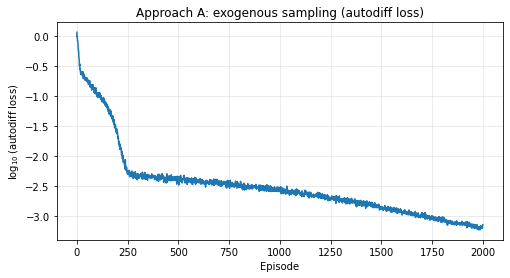

Final loss A = 7.06e-04


In [13]:
# Reset RNG so A and B see the same network init
np.random.seed(SEED); tf.random.set_seed(SEED)

nn_A   = build_network()
opt_A  = make_optimizer(lr=1e-3)
loss_A = []

for ep in range(num_episodes):
    X = get_training_data_exogenous(n_data_A)
    loss, grads = grad_autodiff(X, nn_A)
    opt_A.apply_gradients(zip(grads, nn_A.trainable_variables))
    loss_A.append(loss.numpy())

    if ep % 250 == 0:
        print(f"A | episode {ep:5d} | log10 loss = {np.log10(loss.numpy()):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_A)))
plt.xlabel('Episode'); plt.ylabel(r'$\log_{10}$(autodiff loss)')
plt.title('Approach A: exogenous sampling (autodiff loss)')
plt.grid(True, alpha=0.3); plt.show()
print(f"Final loss A = {loss_A[-1]:.2e}")


### 12.2 Approach B — simulation-based (endogenous) sampling

B | episode     0 | log10 loss = -0.8602


B | episode   250 | log10 loss = -2.6676


B | episode   500 | log10 loss = -2.7557


B | episode   750 | log10 loss = -2.8153


B | episode  1000 | log10 loss = -2.8496


B | episode  1250 | log10 loss = -2.7564


B | episode  1500 | log10 loss = -2.6048


B | episode  1750 | log10 loss = -2.5115


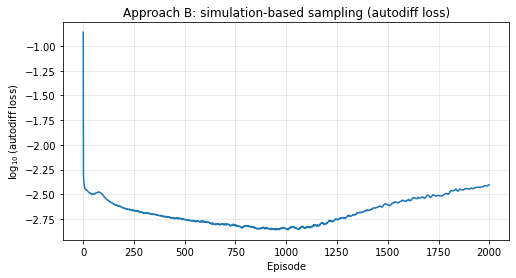

Final loss B = 3.94e-03


In [14]:
# Reset RNG again so the *network init* and *initial state cloud* match a fresh run
np.random.seed(SEED); tf.random.set_seed(SEED)

nn_B   = build_network()
opt_B  = make_optimizer(lr=1e-3)
loss_B = []

X_start_B = make_start_states(n_tracks_B)

for ep in range(num_episodes):
    X, X_start_B = get_training_data_simulation(X_start_B, nn_B, n_sim_periods)
    loss, grads  = grad_autodiff(X, nn_B)
    opt_B.apply_gradients(zip(grads, nn_B.trainable_variables))
    loss_B.append(loss.numpy())

    if ep % 250 == 0:
        print(f"B | episode {ep:5d} | log10 loss = {np.log10(loss.numpy()):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_B)))
plt.xlabel('Episode'); plt.ylabel(r'$\log_{10}$(autodiff loss)')
plt.title('Approach B: simulation-based sampling (autodiff loss)')
plt.grid(True, alpha=0.3); plt.show()
print(f"Final loss B = {loss_B[-1]:.2e}")


## 13. Side-by-side comparison

We compare the two approaches on equal footing — same architecture, same loss,
same training budget, no pre-training, no loss balancing. Differences come from
*sampling alone*.

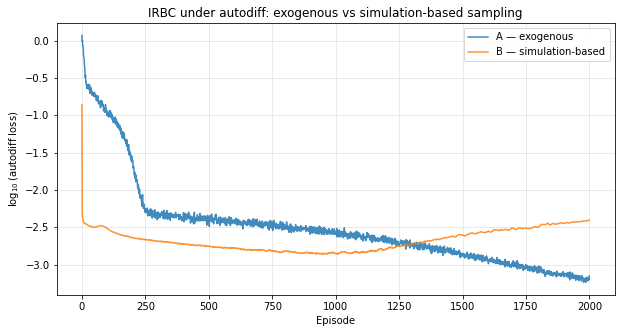

Final losses (autodiff):
  A (exogenous)         : 7.06e-04
  B (simulation-based)  : 3.94e-03


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.log10(np.array(loss_A)), label='A — exogenous',         alpha=0.85)
ax.plot(np.log10(np.array(loss_B)), label='B — simulation-based',  alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel(r'$\log_{10}$(autodiff loss)')
ax.set_title('IRBC under autodiff: exogenous vs simulation-based sampling')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

print(f"Final losses (autodiff):")
print(f"  A (exogenous)         : {loss_A[-1]:.2e}")
print(f"  B (simulation-based)  : {loss_B[-1]:.2e}")


## 14. Solution diagnostics on a simulated test set

We evaluate per-equation residuals on a fresh batch of 2000 simulated states under
each network. This is the right test set because it reflects the *ergodic*
distribution that matters in production use of the policy.

In [16]:
def diagnostics(nn, label, n_test=2000):
    Xs = make_start_states(128)
    X_test, _ = get_training_data_simulation(Xs, nn, n_test // 128 + 1)
    X_test    = X_test[:n_test]
    loss_t, e_t, arc_t, fb_t = compute_cost_autodiff(X_test, nn)
    print(f"--- {label} ---")
    print(f"  test-set autodiff loss = {loss_t.numpy():.2e}")
    for j in range(N_COUNTRIES):
        e_abs = np.abs(e_t[j].numpy())
        print(f"  Euler {j+1}:  mean |.| = {np.mean(e_abs):.2e},  max |.| = {np.max(e_abs):.2e}")
    arc_abs = np.abs(arc_t.numpy())
    print(f"  ARC      :  mean |.| = {np.mean(arc_abs):.2e},  max |.| = {np.max(arc_abs):.2e}")
    for j in range(N_COUNTRIES):
        fb_abs = np.abs(fb_t[j].numpy())
        print(f"  FB    {j+1}:  mean |.| = {np.mean(fb_abs):.2e},  max |.| = {np.max(fb_abs):.2e}")
    return X_test

X_test_A = diagnostics(nn_A, "Approach A (exogenous)")
print()
X_test_B = diagnostics(nn_B, "Approach B (simulation-based)")


--- Approach A (exogenous) ---
  test-set autodiff loss = 4.08e-04
  Euler 1:  mean |.| = 1.11e-02,  max |.| = 1.70e-02
  Euler 2:  mean |.| = 6.84e-03,  max |.| = 1.56e-02
  ARC      :  mean |.| = 4.27e-03,  max |.| = 1.41e-02
  FB    1:  mean |.| = 1.06e-02,  max |.| = 1.68e-02
  FB    2:  mean |.| = 7.92e-03,  max |.| = 1.54e-02



--- Approach B (simulation-based) ---
  test-set autodiff loss = 6.85e-01
  Euler 1:  mean |.| = 9.58e-02,  max |.| = 7.12e-01
  Euler 2:  mean |.| = 1.32e-01,  max |.| = 1.32e+00
  ARC      :  mean |.| = 1.67e-01,  max |.| = 1.58e+00
  FB    1:  mean |.| = 1.21e-01,  max |.| = 1.97e+00
  FB    2:  mean |.| = 1.22e-01,  max |.| = 1.99e+00


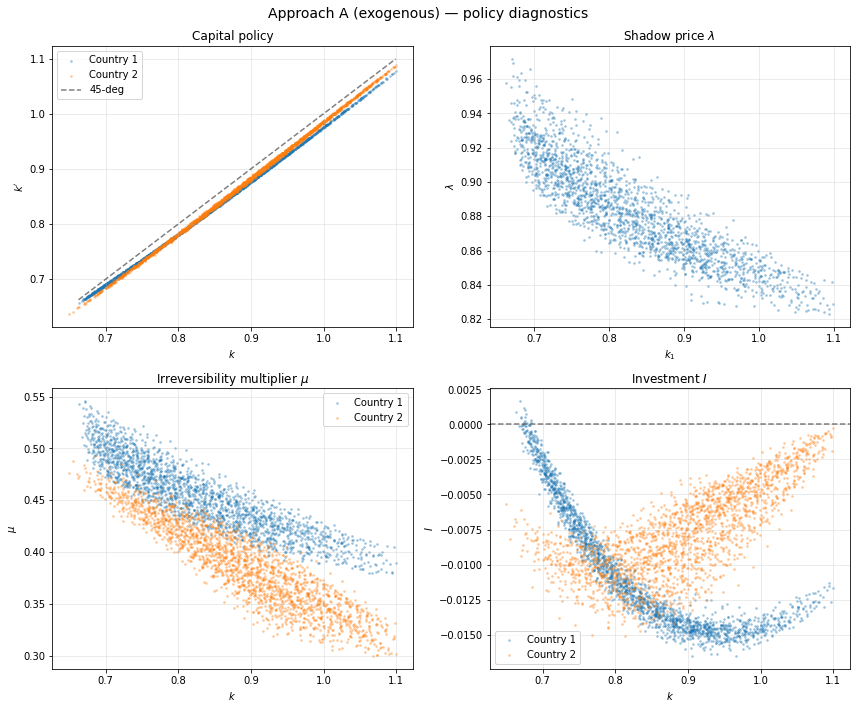

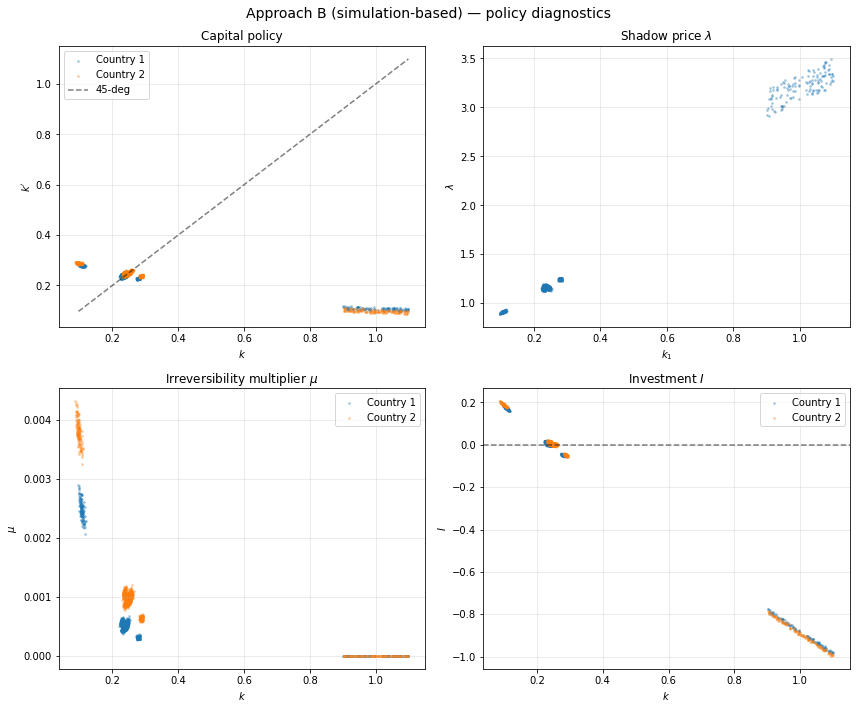

In [17]:
def policy_plots(nn, X_test, title):
    P = nn(X_test).numpy()
    X = X_test.numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=14)

    for j in range(N_COUNTRIES):
        axes[0, 0].scatter(X[:, j], P[:, j], s=3, alpha=0.3, label=f"Country {j+1}")
    k_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 10)
    axes[0, 0].plot(k_range, k_range, 'k--', alpha=0.5, label='45-deg')
    axes[0, 0].set_xlabel('$k$'); axes[0, 0].set_ylabel(r"$k'$")
    axes[0, 0].set_title("Capital policy"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].scatter(X[:, 0], P[:, N_COUNTRIES], s=3, alpha=0.3)
    axes[0, 1].set_xlabel('$k_1$'); axes[0, 1].set_ylabel(r'$\lambda$')
    axes[0, 1].set_title(r'Shadow price $\lambda$'); axes[0, 1].grid(True, alpha=0.3)

    for j in range(N_COUNTRIES):
        axes[1, 0].scatter(X[:, j], P[:, N_COUNTRIES + 1 + j], s=3, alpha=0.3,
                           label=f"Country {j+1}")
    axes[1, 0].set_xlabel('$k$'); axes[1, 0].set_ylabel(r'$\mu$')
    axes[1, 0].set_title(r'Irreversibility multiplier $\mu$'); axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    for j in range(N_COUNTRIES):
        I_j = P[:, j] - (1.0 - delta) * X[:, j]
        axes[1, 1].scatter(X[:, j], I_j, s=3, alpha=0.3, label=f"Country {j+1}")
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('$k$'); axes[1, 1].set_ylabel('$I$')
    axes[1, 1].set_title('Investment $I$'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

policy_plots(nn_A, X_test_A, "Approach A (exogenous) — policy diagnostics")
policy_plots(nn_B, X_test_B, "Approach B (simulation-based) — policy diagnostics")


## 15. Ergodic distribution

If both training runs converge to the same equilibrium policy, the long-run
distributions of $(k_1, k_2)$ should look the same — both centred on the steady
state $k_{\rm ss} = 1$ with a "cigar" along the diagonal driven by the aggregate
shock.

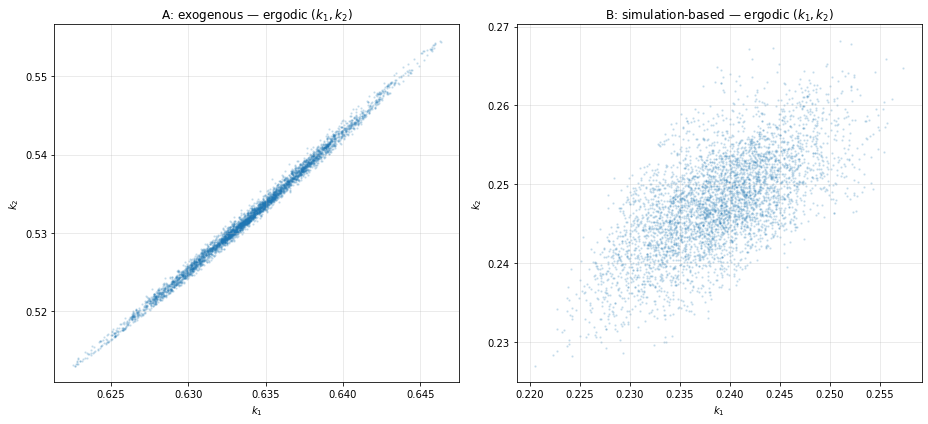

In [18]:
def ergodic_scatter(nn, ax, title, n_long=5000, burn=500):
    ss = np.zeros((1, n_states), dtype=np.float32)
    for j in range(N_COUNTRIES): ss[0, j] = k_ss
    sim = sim_periods(tf.constant(ss), nn, n_long)
    sim = sim[burn:]
    ax.scatter(sim[:, 0, 0], sim[:, 0, 1], s=2, alpha=0.15)
    ax.set_xlabel('$k_1$'); ax.set_ylabel('$k_2$')
    ax.set_title(title); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
ergodic_scatter(nn_A, axes[0], "A: exogenous — ergodic $(k_1, k_2)$")
ergodic_scatter(nn_B, axes[1], "B: simulation-based — ergodic $(k_1, k_2)$")
plt.tight_layout(); plt.show()


## 16. Take-away

What changed between Day 3 nb 01 and this notebook:

| Day 3 nb 01 | This notebook |
|---|---|
| 4 hand-derived analytic helpers (`production_k`, `mpk`, `adj_cost_k`, `adj_cost_kp`) | 0 — replaced by two `tape.gradient` calls per country |
| Euler residual written out by hand | Comes out of the autodiff template `partial_2 Pi + beta * E[partial_1 Pi]` |
| 4 sampling/regularisation strategies (A, B, C, D) | Just A and B — focused comparison of sampling alone |

What stayed the same:

- Network architecture (2 × 64 swish + softplus),
- ARC and Fischer–Burmeister (algebraic / KKT, not envelope outputs),
- Quadrature (Gauss–Hermite tensor product, Q = 3 per dimension),
- Cross-check 1 verifies the autodiff Euler residual *is* the Day 3 hand-derived
  Euler residual, to machine precision.

The autodiff template generalises trivially: any planner problem whose period
contribution can be written as $\Pi^j(k_{\text{in}}, k_{\text{out}}, z; \lambda, \mu^j)$
admits Euler residuals of the form $\partial_2 \Pi^j + \beta\,\mathbb{E}[\partial_1 \Pi^j]$.
Algebraic constraints (ARC) and KKT complementarity (FB) stay hand-coded — autodiff
has nothing to add there.

### Suggested follow-on exercises

1. **Add steady-state pre-training** (Day 3 Approach C) on top of either A or B.
   Recover the Day 3 final loss of $\sim 10^{-7}$ in 2000 episodes.
2. **Add ReLoBRaLo** to balance the $2N+1$ component losses. Compare against
   Day 3 Approach D.
3. **Increase $N$.** With $N \ge 4$ the Gauss–Hermite tensor product
   ($Q^{N+1}$ nodes) becomes expensive. Replace with a monomial cubature or
   quasi-Monte Carlo and confirm the autodiff template needs no other change —
   only `quad_nodes_tf`/`quad_weights_tf` move.
4. **CES production / Epstein–Zin preferences.** Edit the `Pi` primitive and re-run.